In [1]:
pip install scikeras

In [2]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

Task 1: Dataset Exploration

In [4]:
from tensorflow.keras.datasets import fashion_mnist

In [5]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [6]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


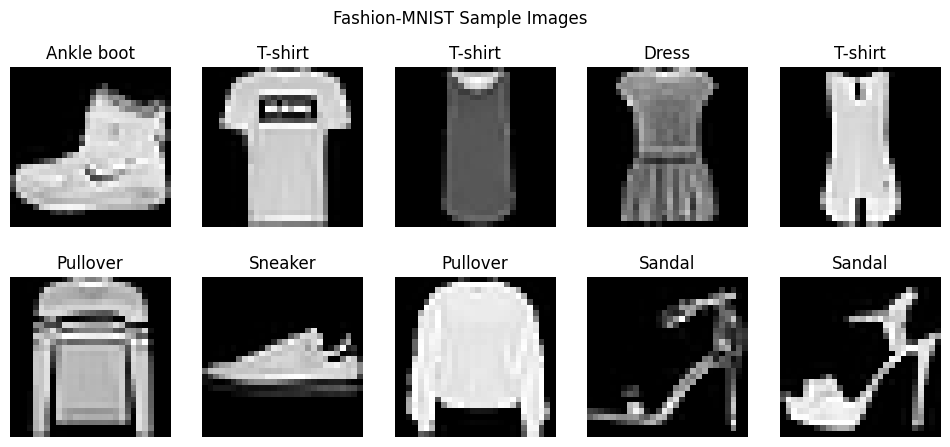

In [7]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Images")

plt.savefig("Sample_Images.png", dpi=300, bbox_inches="tight")
plt.savefig("Sample_Images.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

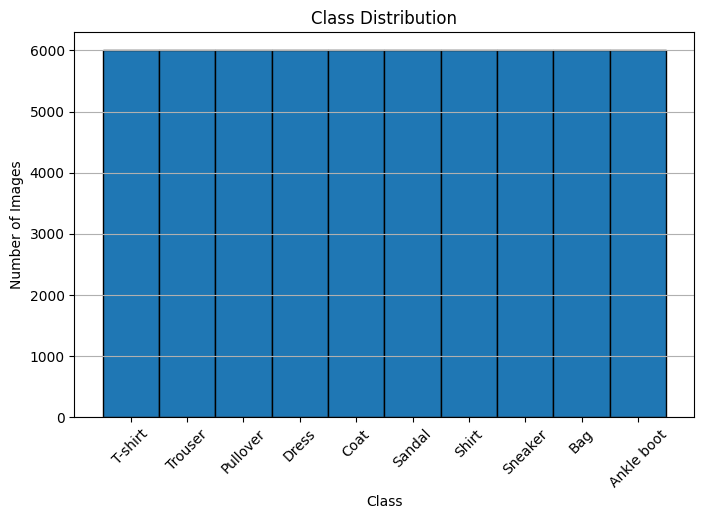

In [8]:
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=np.arange(11)-0.5, edgecolor='black')

plt.xticks(range(10), class_names, rotation=45)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.grid(axis='y')

plt.savefig("Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("Class_Distribution.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

Task 2: Data Preprocessing

In [9]:
print(x_train.shape)

(60000, 28, 28)


In [10]:
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

In [11]:
x_train = x_train/255.0
x_test = x_test/255.0

In [12]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [13]:
print("Tensor Shape before Preprocessing:")
print(x_train.shape)
print("Tensor Shape after Preprocessing:")
print(y_train_cat.shape)

Tensor Shape before Preprocessing:
(60000, 784)
Tensor Shape after Preprocessing:
(60000, 10)


Task 3: Model Construction

In [14]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Training

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8160 - loss: 0.5173 - val_accuracy: 0.8570 - val_loss: 0.4026
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8622 - loss: 0.3800 - val_accuracy: 0.8683 - val_loss: 0.3631
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8740 - loss: 0.3399 - val_accuracy: 0.8712 - val_loss: 0.3546
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8836 - loss: 0.3138 - val_accuracy: 0.8591 - val_loss: 0.3777
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8899 - loss: 0.2956 - val_accuracy: 0.8783 - val_loss: 0.3483
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2824 - val_accuracy: 0.8834 - val_loss: 0.3338
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9004 - loss: 0.2697 - val_accuracy: 0.8761 - val_loss: 0.3460
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9036 - loss: 0.2565 

Task 5: Evaluation

In [18]:
pred = model.predict(x_test)

pred_classes = np.argmax(pred,axis=1)
true_classes = np.argmax(y_test_cat,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:",
      accuracy_score(true_classes,pred_classes))

print(classification_report(
      true_classes,
      pred_classes))

Accuracy: 0.8792
              precision    recall  f1-score   support

           0       0.87      0.75      0.80      1000
           1       0.99      0.97      0.98      1000
           2       0.78      0.81      0.79      1000
           3       0.81      0.94      0.87      1000
           4       0.80      0.81      0.81      1000
           5       0.97      0.97      0.97      1000
           6       0.72      0.66      0.69      1000
           7       0.92      0.97      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.98      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



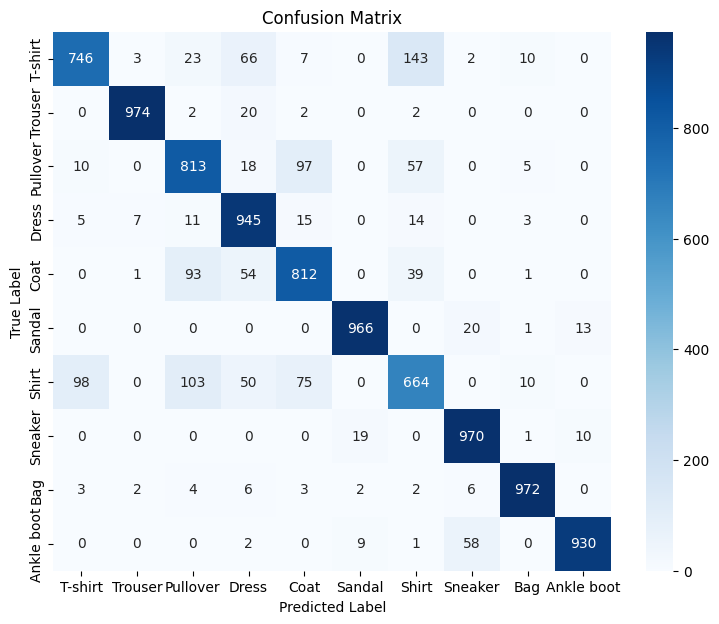

In [20]:
import seaborn as sns

cm = confusion_matrix(true_classes,pred_classes)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("Confusion_Matrix.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

Task 6: Hyperparameter Optimization

In [21]:
def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 activation='relu',
                 optimizer='adam',
                 learning_rate=0.001,
                 dropout_rate=0.0):

    model = Sequential()
    model.add(Dense(hidden_neurons,
                    activation=activation,
                    input_shape=(784,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers-1):
        model.add(Dense(hidden_neurons,
                        activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)

    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [22]:
clf = KerasClassifier(model=create_model)

In [23]:
param_dist = {
    "model__hidden_layers": [1,2,3],
    "model__hidden_neurons": [32,64,128,256],
    "model__learning_rate": [0.1,0.01,0.001],
    "model__activation": ["relu","tanh","sigmoid"],
    "model__optimizer": ["adam","sgd","rmsprop"],
    "model__dropout_rate": [0.0,0.2,0.5],
    "batch_size": [16,32,64,128],
    "epochs": [10,20,30]
}

In [24]:
import sklearn
print(sklearn.__version__)

1.5.2


In [25]:
search = RandomizedSearchCV(
    clf,
    param_dist,
    cv=5,
    n_iter=10
)

search.fit(x_train,y_train_cat)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7638 - loss: 0.7453
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8151 - loss: 0.5662
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8254 - loss: 0.5472
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8285 - loss: 0.5401
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8269 - loss: 0.5592
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8249 - loss: 0.5741
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8242 - loss: 0.5803
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8233 - loss: 0.6029
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8228 - loss: 0.6035
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8233 - loss: 0.6036
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7666 - loss: 0.7183
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8173 - loss: 0.5671
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8256 - loss: 0.5594
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8272 - loss: 0.5752
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8280 - loss: 0.5826
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8316 - loss: 0.5887
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8235 - loss: 0.5959
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8275 - loss: 0.6063
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8238 - loss: 0.6247
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8278 - loss: 0.5958
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7816 - loss: 0.6618
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8433 - loss: 0.4449
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.4056
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8629 - loss: 0.3820
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8681 - loss: 0.3656
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8740 - loss: 0.3533
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8763 - loss: 0.3433
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8799 - loss: 0.3339
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3259
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8841 - loss: 0.3200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8006 - loss: 0.5392
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8564 - loss: 0.3852
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8739 - loss: 0.3384
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8827 - loss: 0.3141
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8898 - loss: 0.2941
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8971 - loss: 0.2751
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9007 - loss: 0.2632
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9064 - loss: 0.2491
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9094 - loss: 0.2384
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9136 - loss: 0.2283
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9180 - loss: 0.2179
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7c9ca325bce0>),
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']})

In [32]:
import pandas as pd

results = pd.DataFrame(search.cv_results_)

In [26]:
print(search.best_params_)
print(search.best_score_)

{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 3, 'model__dropout_rate': 0.0, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}
0.8924833333333334


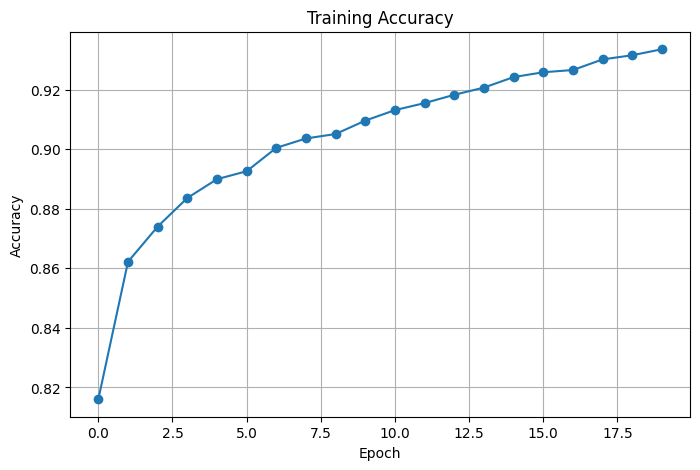

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],
         marker='o',
         linewidth=2)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("Training_Accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("Training_Accuracy.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

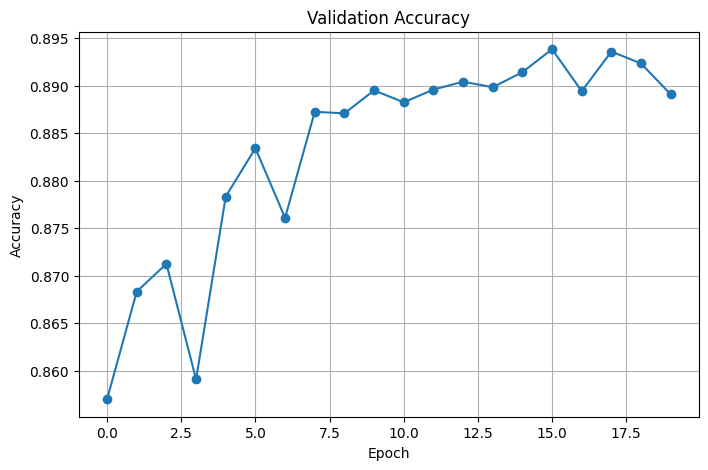

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_accuracy"],
         marker='o',
         linewidth=2)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("Validation_Accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("Validation_Accuracy.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

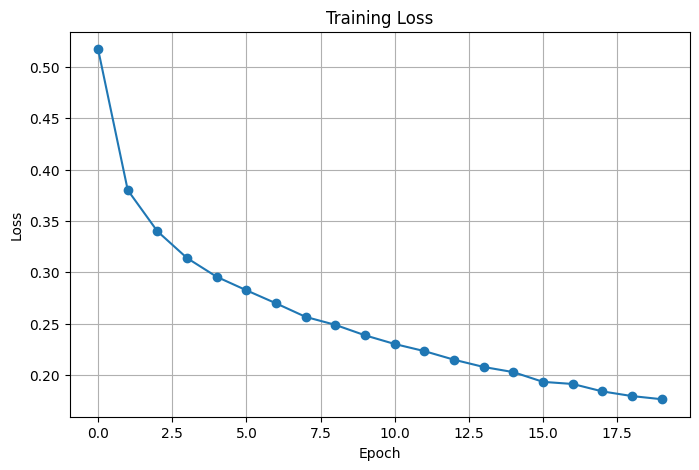

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],
         marker='o',
         linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("Training_Loss.png", dpi=300, bbox_inches="tight")
plt.savefig("Training_Loss.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

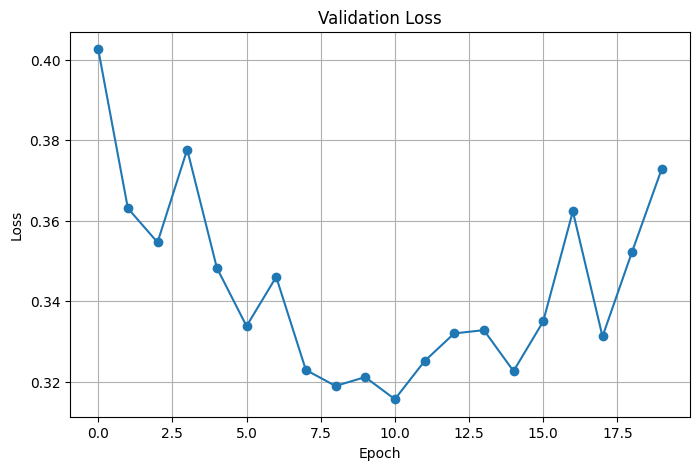

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"],
         marker='o',
         linewidth=2)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("Validation_Loss.png", dpi=300, bbox_inches="tight")
plt.savefig("Validation_Loss.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

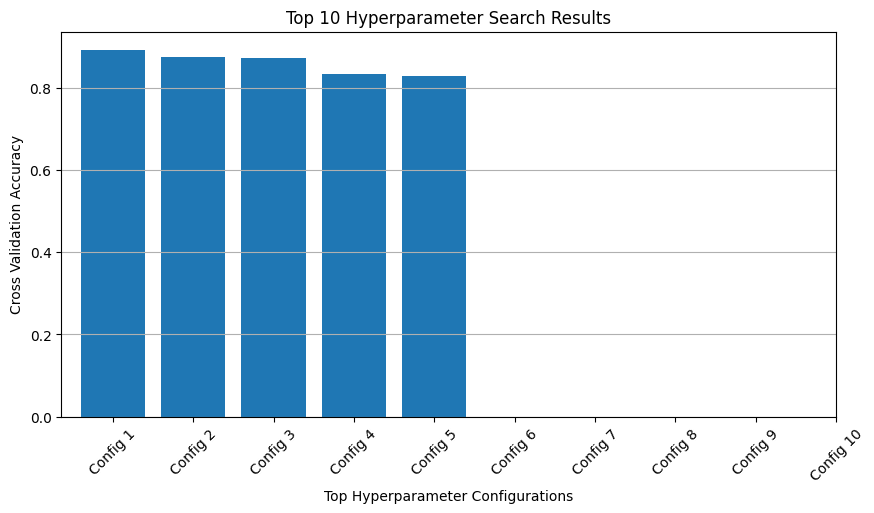

In [33]:
results = results.sort_values(
    "mean_test_score",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    range(10),
    results["mean_test_score"].head(10)
)

plt.xticks(range(10),
           [f"Config {i}" for i in range(1,11)],
           rotation=45)

plt.ylabel("Cross Validation Accuracy")
plt.xlabel("Top Hyperparameter Configurations")
plt.title("Top 10 Hyperparameter Search Results")

plt.grid(axis='y')

plt.savefig("Hyperparameter_Search.png",
            dpi=300,
            bbox_inches="tight")

plt.savefig("Hyperparameter_Search.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

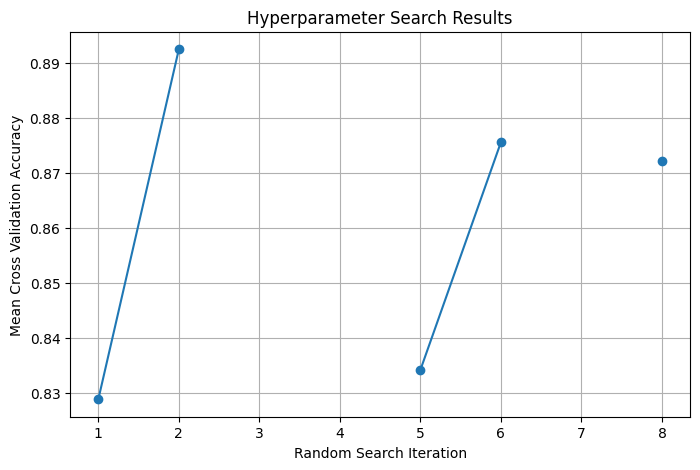

In [37]:
results = search.cv_results_

plt.figure(figsize=(8,5))

plt.plot(
    results["mean_test_score"],
    marker='o'
)

plt.title("Hyperparameter Search Results")
plt.xlabel("Random Search Iteration")
plt.ylabel("Mean Cross Validation Accuracy")
plt.grid(True)

plt.savefig(
    "hyperparameter_search_results.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("hyperparameter_search_results.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [42]:
best_model = search.best_estimator_

optimized_prediction = best_model.predict(x_test)
optimized_prediction = np.argmax(
    optimized_prediction,
    axis=1
)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)

optimized_precision = precision_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

print("Optimized Model Performance")
print("----------------------------")
print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1-score : {optimized_f1:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


NameError: name 'precision_score' is not defined

In [41]:
baseline_accuracy = accuracy_score(
    y_test,
    pred_classes
)

plt.figure(figsize=(6,5))

plt.bar(
    ["Baseline","Optimized"],
    [baseline_accuracy, optimized_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model")

plt.ylim(0.80,1.00)

for i, value in enumerate([baseline_accuracy, optimized_accuracy]):
    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.savefig(
    "Baseline_vs_Optimized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Baseline_vs_Optimized.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

NameError: name 'optimized_accuracy' is not defined

<Figure size 600x500 with 0 Axes>